# Phân Tích Dữ Liệu Sinh Viên
## Data Analysis & Visualization Project

Dự án phân tích toàn diện dữ liệu sinh viên từ làm sạch đến trực quan hóa và đưa ra đề xuất quản lý.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import re

# warnings.filterwarnings('ignore')
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10



✓ Libraries imported successfully


## Load Data
Đọc dữ liệu từ CSV và chuyển sang XLSX format

In [ ]:
df_raw = pd.read_excel('../crawl/crawl_data/crawled_data.xlsx')

print(f"Kích thước dữ liệu ban đầu: {df_raw.shape}")
print(f"\nTên cột ban đầu:")
print(df_raw.columns.tolist())
print(f"\n5 dòng đầu tiên:")
df_raw.head()

Kích thước dữ liệu ban đầu: (400, 13)

Tên cột ban đầu:
['column_1', 'column_2', 'column_3', 'column_4', 'column_5', 'column_6', 'column_7', 'column_8', 'column_9', 'column_10', 'column_11', 'column_12', 'column_13']

5 dòng đầu tiên:


,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13
0,NaN,SV1000,Khoa Hải Bùi,27/09/2003,09 7457 9208,dangjane@example.com,hà nội,NaN,4.5510,5.2921,Err,NaN,NaN
1,NaN,SV1001,Quý cô Hương Đặng,10/12/2003,2 3815 6873,maijane@example.org,Hải Phòng,8.6772,2.5911,NaN,Err,NaN,NaN
2,NaN,SV1002,Nam Trần,2005-08-16,+84-73-982 5638,—,Hải Phòng,6.1120,3.0486,9.2764,6.15,NaN,NaN
3,NaN,SV1003,Tú Lê,11/10/2005,+84 05 8860084,—,HN,-3.2000,0.0487,4.0957,0.31,NaN,NaN
4,NaN,SV1004,Phương Mai Bảo Lê,13/03/2004,(00) 4680 9376,jle@example.com,Cần Thơ,5.3585,3.2529,-2.8100,1.93,NaN,NaN


# Làm sạch dữ liệu thô

## 1. Làm sạch cấu trúc dữ liệu

In [ ]:
# Tạo bản sao để xử lý
df = df_raw.copy()

# Log quá trình làm sạch
cleaning_log = []

# Đổi tên cột theo cấu trúc chuẩn
df.columns = ['Empty', 'ID', 'Fullname', 'Birthday', 'Phone', 'Email', 'Hometown', 
              'Math', 'Literature', 'Eng', 'Avg', 'Action1', 'Action2']

# Loại bỏ cột rỗng và 2 cột Action
df = df.drop(columns=['Empty', 'Action1', 'Action2'])
cleaning_log.append(f"Đã loại bỏ 3 cột không cần thiết (Empty, Action1, Action2)")

print("Cấu trúc dữ liệu sau khi chuẩn hóa:")
print(f"Kích thước: {df.shape}")
print(f"Các cột: {df.columns.tolist()}")
df.head(5)

,ID,Fullname,Birthday,Phone,Email,Hometown,Math,Literature,Eng,Avg
0,SV1000,Khoa Hải Bùi,27/09/2003,09 7457 9208,dangjane@example.com,hà nội,NaN,4.5510,5.2921,Err
1,SV1001,Quý cô Hương Đặng,10/12/2003,2 3815 6873,maijane@example.org,Hải Phòng,8.6772,2.5911,NaN,Err
2,SV1002,Nam Trần,2005-08-16,+84-73-982 5638,—,Hải Phòng,6.1120,3.0486,9.2764,6.15
3,SV1003,Tú Lê,11/10/2005,+84 05 8860084,—,HN,-3.2000,0.0487,4.0957,0.31
4,SV1004,Phương Mai Bảo Lê,13/03/2004,(00) 4680 9376,jle@example.com,Cần Thơ,5.3585,3.2529,-2.8100,1.93


In [ ]:
# Kiểm tra và xử lý trùng ID
duplicated_ids = df[df['ID'].duplicated(keep=False)]
if len(duplicated_ids) > 0:
    print(f"Phát hiện {len(duplicated_ids)} ID bị trùng")
    df = df.drop_duplicates(subset=['ID'], keep='first')
    cleaning_log.append(f"Đã xóa {len(duplicated_ids)} dòng bị trùng ID")
else:
    print("Không có ID bị trùng")

# Xóa dòng toàn bộ giá trị là NaN
rows_before = len(df)
df = df.dropna(how='all')
rows_removed = rows_before - len(df)
if rows_removed > 0:
    cleaning_log.append(f"Đã xóa {rows_removed} dòng toàn bộ NaN")

print(f"Dữ liệu sau khi xử lý cấu trúc: {df.shape}")

✓ Không có ID bị trùng

Dữ liệu sau khi xử lý cấu trúc: (400, 10)


## 2. Làm sạch dữ liệu cá nhân sinh viên

### Xử lý Fullname

In [ ]:
# Làm sạch Fullname
def clean_fullname(name):
    if pd.isna(name):
        return np.nan
    # Loại bỏ các tiền tố như "Bà", "Ông", "Anh", "Chị", "Cô", "Bác", "Quý ông", "Quý cô"
    prefixes = ['Bà ', 'Ông ', 'Anh ', 'Chị ', 'Cô ', 'Bác ', 'Quý ông ', 'Quý cô ']
    for prefix in prefixes:
        if str(name).startswith(prefix):
            name = str(name).replace(prefix, '', 1)
    
    # Loại bỏ khoảng trắng dư thừa
    name = ' '.join(str(name).split())
    
    # Chuẩn hóa viết hoa chữ cái đầu mỗi từ
    name = name.title()
    
    return name

df['Fullname'] = df['Fullname'].apply(clean_fullname)

# Xóa dòng có Fullname rỗng
empty_names = df['Fullname'].isna().sum()
df = df.dropna(subset=['Fullname'])
if empty_names > 0:
    cleaning_log.append(f"Đã xóa {empty_names} dòng có Fullname rỗng")

print("Đã làm sạch Fullname")
print(f"Ví dụ Fullname sau khi làm sạch:")
print(df['Fullname'].head(10).tolist())

✓ Đã làm sạch Fullname
Ví dụ Fullname sau khi làm sạch:
['Khoa Hải Bùi', 'Hương Đặng', 'Nam Trần', 'Tú Lê', 'Phương Mai Bảo Lê', 'Nhật Đặng', 'Tú Đặng', 'Lan Dương', 'Hồng Bùi', 'Bảo Mai']


### Xử lý Birthday và tính Age

In [ ]:
# Làm sạch Birthday
def parse_birthday(date_str):
    if pd.isna(date_str) or str(date_str).lower() == 'unknown':
        return np.nan
    
    date_str = str(date_str).strip()
    
    # Thử các định dạng khác nhau
    formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y']
    
    for fmt in formats:
        try:
            date_obj = datetime.strptime(date_str, fmt)
            # Kiểm tra ngày hợp lệ (không phải ngày như 32/13/2002)
            if 1990 <= date_obj.year <= 2010 and 1 <= date_obj.month <= 12 and 1 <= date_obj.day <= 31:
                return date_obj.strftime('%Y-%m-%d')
        except:
            continue
    
    return np.nan

# Áp dụng làm sạch
invalid_birthdays_before = df['Birthday'].isna().sum()
df['Birthday'] = df['Birthday'].apply(parse_birthday)
invalid_birthdays_after = df['Birthday'].isna().sum()
cleaned_birthdays = invalid_birthdays_after - invalid_birthdays_before

if cleaned_birthdays > 0:
    cleaning_log.append(f"Đã set {cleaned_birthdays} ngày sinh không hợp lệ thành NaN")

# Tính tuổi
def calculate_age(birthday):
    if pd.isna(birthday):
        return np.nan
    try:
        birth_date = datetime.strptime(birthday, '%Y-%m-%d')
        today = datetime(2026, 1, 20)  # Current date
        age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
        return age
    except:
        return np.nan

df['Age'] = df['Birthday'].apply(calculate_age)

# Loại các giá trị tuổi không hợp lý
invalid_age_count = ((df['Age'] < 17) | (df['Age'] > 30)).sum()
df.loc[(df['Age'] < 17) | (df['Age'] > 30), 'Age'] = np.nan

if invalid_age_count > 0:
    cleaning_log.append(f"Đã set {invalid_age_count} tuổi không hợp lý (<17 hoặc >30) thành NaN")

print("Đã làm sạch Birthday và tính Age")
print(f"Số ngày sinh hợp lệ: {df['Birthday'].notna().sum()}")
print(f"Số tuổi hợp lệ: {df['Age'].notna().sum()}")
print(f"Khoảng tuổi: {df['Age'].min():.0f} - {df['Age'].max():.0f}")

✓ Đã làm sạch Birthday và tính Age
Số ngày sinh hợp lệ: 316
Số tuổi hợp lệ: 316
Khoảng tuổi: 18 - 24


### Xử lý Phone

In [ ]:
# Làm sạch Phone
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    
    # Loại bỏ toàn bộ ký tự không phải số
    phone_digits = re.sub(r'\D', '', str(phone))
    
    # Kiểm tra độ dài hợp lệ (9-11 số)
    if len(phone_digits) < 9 or len(phone_digits) > 11:
        return np.nan
    
    # Chuẩn hóa đầu số về 0
    if phone_digits.startswith('84'):
        phone_digits = '0' + phone_digits[2:]
    
    # Kiểm tra đầu số hợp lệ (phải bắt đầu bằng 0)
    if not phone_digits.startswith('0'):
        return np.nan
    
    return phone_digits

invalid_phones_before = df['Phone'].isna().sum()
df['Phone'] = df['Phone'].apply(clean_phone)
invalid_phones_after = df['Phone'].isna().sum()
cleaned_phones = invalid_phones_after - invalid_phones_before

if cleaned_phones > 0:
    cleaning_log.append(f"Đã set {cleaned_phones} số điện thoại không hợp lệ thành NaN")

print("Đã làm sạch Phone")
print(f"Số điện thoại hợp lệ: {df['Phone'].notna().sum()}")
print(f"Ví dụ: {df['Phone'].dropna().head(5).tolist()}")

✓ Đã làm sạch Phone
Số điện thoại hợp lệ: 310
Ví dụ: ['0974579208', '0739825638', '0058860084', '0046809376', '0397019346']


### Xử lý Email

In [ ]:
# Làm sạch Email
def clean_email(email):
    if pd.isna(email) or str(email) == '—' or str(email).strip() == '':
        return np.nan
    
    email = str(email).strip()
    
    # Kiểm tra phải chứa ký tự @
    if '@' not in email:
        return np.nan
    
    # Kiểm tra format cơ bản
    email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    if not re.match(email_pattern, email):
        return np.nan
    
    return email.lower()

invalid_emails_before = df['Email'].isna().sum()
df['Email'] = df['Email'].apply(clean_email)
invalid_emails_after = df['Email'].isna().sum()
cleaned_emails = invalid_emails_after - invalid_emails_before

if cleaned_emails > 0:
    cleaning_log.append(f"Đã set {cleaned_emails} email không hợp lệ thành NaN")

print("Đã làm sạch Email")
print(f"Email hợp lệ: {df['Email'].notna().sum()}")
print(f"Ví dụ: {df['Email'].dropna().head(5).tolist()}")

✓ Đã làm sạch Email
Email hợp lệ: 335
Ví dụ: ['dangjane@example.com', 'maijane@example.org', 'jle@example.com', 'janehoang@example.net', 'dangjane@example.com']


### Xử lý Hometown

In [ ]:
# Làm sạch và chuẩn hóa Hometown
def clean_hometown(hometown):
    if pd.isna(hometown):
        return 'Khác'
    
    hometown = str(hometown).strip().lower()
    
    # Chuẩn hóa Hà Nội
    if hometown in ['hn', 'hà nội', 'ha noi', 'hanoi', 'ha nioj']:
        return 'Hà Nội'
    
    # Chuẩn hóa TP.HCM
    if hometown in ['hcm', 'tp hcm', 'tp.hcm', 'ho chi minh city', 'hồ chí minh', 'tp hồ chí minh']:
        return 'TP.HCM'
    
    # Các địa phương khác
    return 'Khác'

df['Hometown'] = df['Hometown'].apply(clean_hometown)

print("Đã làm sạch Hometown")
print("\nPhân bố quê quán:")
print(df['Hometown'].value_counts())

✓ Đã làm sạch Hometown

Phân bố quê quán:
Hometown
Khác      193
TP.HCM    112
Hà Nội     95
Name: count, dtype: int64


## 3. Làm sạch dữ liệu điểm số

In [ ]:
# Làm sạch điểm số
def clean_score(score):
    if pd.isna(score) or str(score).lower() == 'err' or str(score).strip() == '':
        return np.nan
    
    try:
        score_value = float(score)
        # Kiểm tra điểm hợp lệ (0-10)
        if 0 <= score_value <= 10:
            return round(score_value, 2)
        else:
            return np.nan
    except:
        return np.nan

# Áp dụng cho các môn
score_columns = ['Math', 'Literature', 'Eng']

for col in score_columns:
    invalid_before = df[col].isna().sum()
    df[col] = df[col].apply(clean_score)
    invalid_after = df[col].isna().sum()
    cleaned = invalid_after - invalid_before
    if cleaned > 0:
        cleaning_log.append(f"Đã set {cleaned} điểm {col} không hợp lệ thành NaN")

print("Đã làm sạch điểm số")
print("\nSố missing values:")
for col in score_columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {col}: {missing_count} ({missing_pct:.2f}%)")

✓ Đã làm sạch điểm số

Số missing values:
  Math: 90 (22.50%)
  Literature: 100 (25.00%)
  Eng: 100 (25.00%)


### Xử lý Missing Values và Outliers

In [ ]:
# Xử lý missing values theo quy tắc
for col in score_columns:
    missing_pct = (df[col].isna().sum() / len(df)) * 100
    
    if missing_pct <= 10:
        # Điền bằng median
        median_value = df[col].median()
        filled_count = df[col].isna().sum()
        df[col].fillna(median_value, inplace=True)
        cleaning_log.append(f"Đã điền {filled_count} missing {col} bằng median ({median_value:.2f})")
        print(f"Điền {col} missing (≤10%) bằng median: {median_value:.2f}")
    else:
        print(f"Lưu ý: {col} có >10% missing ({missing_pct:.2f}%), giữ NaN")

# Phát hiện outliers (điểm = 100 đã được xử lý ở bước clean_score)
print("\nOutliers đã được xử lý trong quá trình làm sạch")

⚠️ Math có >10% missing (22.50%), giữ NaN
⚠️ Literature có >10% missing (25.00%), giữ NaN
⚠️ Eng có >10% missing (25.00%), giữ NaN

✓ Outliers đã được xử lý trong quá trình làm sạch


### Tính lại điểm trung bình (Avg)

In [ ]:
# Tính lại Avg = mean(Math, Literature, Eng)
df['Avg'] = df[['Math', 'Literature', 'Eng']].mean(axis=1).round(2)

cleaning_log.append(f"Đã tính lại điểm trung bình (Avg) cho tất cả sinh viên")

print("Đã tính lại điểm trung bình")
print("\nThống kê Avg:")
print(df['Avg'].describe())

✓ Đã tính lại điểm trung bình

Thống kê Avg:
count    397.000000
mean       4.984030
std        2.147624
min        0.150000
25%        3.520000
50%        5.150000
75%        6.470000
max        9.890000
Name: Avg, dtype: float64


### Tóm tắt quá trình làm sạch

In [ ]:
# In log quá trình làm sạch
print("=" * 70)
print("TÓNG TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU")
print("=" * 70)
print(f"\nSố dòng ban đầu: {len(df_raw)}")
print(f"Số dòng sau làm sạch: {len(df)}")
print(f"Số dòng đã xóa: {len(df_raw) - len(df)}")
print(f"\nChi tiết các thao tác:")
for i, log in enumerate(cleaning_log, 1):
    print(f"  {i}. {log}")
print("=" * 70)

📋 TÓNG TẮT QUÁ TRÌNH LÀM SẠCH DỮ LIỆU

✓ Số dòng ban đầu: 400
✓ Số dòng sau làm sạch: 400
✓ Số dòng đã xóa: 0

📝 Chi tiết các thao tác:
  1. ✓ Đã loại bỏ 3 cột không cần thiết (Empty, Action1, Action2)
  2. ✓ Đã set 84 ngày sinh không hợp lệ thành NaN
  3. ✓ Đã set 90 số điện thoại không hợp lệ thành NaN
  4. ✓ Đã set 65 email không hợp lệ thành NaN
  5. ✓ Đã set 57 điểm Math không hợp lệ thành NaN
  6. ✓ Đã set 53 điểm Literature không hợp lệ thành NaN
  7. ✓ Đã set 47 điểm Eng không hợp lệ thành NaN
  8. ✓ Đã tính lại điểm trung bình (Avg) cho tất cả sinh viên


# MỐC 2 - Kiểm tra và xác nhận dữ liệu sạch

In [ ]:
# Kiểm tra dữ liệu sạch
print("=" * 70)
print("KIỂM TRA DỮ LIỆU SAU LÀM SẠCH")
print("=" * 70)

# 1. Kiểm tra điểm nằm trong khoảng 0-10
invalid_scores = 0
for col in score_columns:
    invalid = ((df[col] < 0) | (df[col] > 10)).sum()
    invalid_scores += invalid
    print(f"\n{col}: Không có điểm <0 hoặc >10" if invalid == 0 else f"{col}: Còn {invalid} điểm không hợp lệ")

# 2. Kiểm tra Avg
print(f"\nAvg đã được tính lại chính xác")

# 3. Kiểm tra ngày sinh
invalid_birthdays = df['Birthday'].isna().sum()
print(f"\nNgày sinh: {len(df) - invalid_birthdays} hợp lệ, {invalid_birthdays} NaN")

# 4. Thống kê tổng quan
print(f"\n" + "=" * 70)
print("THỐNG KÊ DỮ LIỆU SẠCH")
print("=" * 70)

for col in score_columns + ['Avg']:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")

print(f"\n" + "=" * 70)
print(f"Tổng số sinh viên hợp lệ: {len(df)}")
print("=" * 70)

🔍 KIỂM TRA DỮ LIỆU SAU LÀM SẠCH

✓ Math: Không có điểm <0 hoặc >10

✓ Literature: Không có điểm <0 hoặc >10

✓ Eng: Không có điểm <0 hoặc >10

✓ Avg đã được tính lại chính xác

✓ Ngày sinh: 316 hợp lệ, 84 NaN

📊 THỐNG KÊ DỮ LIỆU SẠCH

Math:
  Min: 0.01
  Max: 9.95
  Mean: 4.90
  Median: 4.69
  Std: 2.79

Literature:
  Min: 0.04
  Max: 9.94
  Mean: 5.15
  Median: 5.38
  Std: 2.91

Eng:
  Min: 0.01
  Max: 10.00
  Mean: 5.00
  Median: 4.89
  Std: 3.07

Avg:
  Min: 0.15
  Max: 9.89
  Mean: 4.98
  Median: 5.15
  Std: 2.15

✓ Tổng số sinh viên hợp lệ: 400


### So sánh trước và sau làm sạch

In [ ]:
# Bảng so sánh
comparison_df = pd.DataFrame({
    'Metric': ['Số dòng', 'Số cột', 'Math missing', 'Literature missing', 'Eng missing'],
    'Trước làm sạch': [
        len(df_raw),
        len(df_raw.columns),
        f"{df_raw['column_8'].isna().sum()} ({(df_raw['column_8'].isna().sum()/len(df_raw)*100):.1f}%)",
        f"{df_raw['column_9'].isna().sum()} ({(df_raw['column_9'].isna().sum()/len(df_raw)*100):.1f}%)",
        f"{df_raw['column_10'].isna().sum()} ({(df_raw['column_10'].isna().sum()/len(df_raw)*100):.1f}%)"
    ],
    'Sau làm sạch': [
        len(df),
        len(df.columns),
        f"{df['Math'].isna().sum()} ({(df['Math'].isna().sum()/len(df)*100):.1f}%)",
        f"{df['Literature'].isna().sum()} ({(df['Literature'].isna().sum()/len(df)*100):.1f}%)",
        f"{df['Eng'].isna().sum()} ({(df['Eng'].isna().sum()/len(df)*100):.1f}%)"
    ]
})

print("\nSO SÁNH TRƯỚC VÀ SAU LÀM SẠCH:")
print(comparison_df.to_string(index=False))


📊 SO SÁNH TRƯỚC VÀ SAU LÀM SẠCH:
            Metric Trước làm sạch Sau làm sạch
           Số dòng            400          400
            Số cột             13           11
      Math missing      33 (8.2%)   90 (22.5%)
Literature missing     47 (11.8%)  100 (25.0%)
       Eng missing     53 (13.2%)  100 (25.0%)


### Xuất dữ liệu sạch ra file XLSX

In [ ]:
# Xuất ra file XLSX
output_path = 'students_clean.xlsx'
df.to_excel(output_path, index=False, engine='openpyxl')

print(f"\nĐã xuất dữ liệu sạch ra file: {output_path}")
print(f"Kích thước: {df.shape}")
print(f"Các cột: {df.columns.tolist()}")


✓ Đã xuất dữ liệu sạch ra file: students_clean.xlsx
✓ Kích thước: (400, 11)
✓ Các cột: ['ID', 'Fullname', 'Birthday', 'Phone', 'Email', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg', 'Age']


# MỐC 3 - Phân tích mô tả dữ liệu

In [ ]:
# Tổng quan dữ liệu
print("=" * 70)
print("PHÂN TÍCH MÔ TẢ DỮ LIỆU")
print("=" * 70)

print(f"\nTổng số sinh viên hợp lệ: {len(df)}")
print("\nTỷ lệ thiếu dữ liệu theo cột:")

for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = (missing_count / len(df)) * 100
    print(f"  {col:15} : {missing_count:3} ({missing_pct:5.2f}%)")

print("\nĐiểm trung bình các môn:")
print(f"  Toán (Math):        {df['Math'].mean():.2f}")
print(f"  Văn (Literature):   {df['Literature'].mean():.2f}")
print(f"  Anh (Eng):          {df['Eng'].mean():.2f}")
print(f"  Trung bình (Avg):   {df['Avg'].mean():.2f}")

📊 PHÂN TÍCH MÔ TẢ DỮ LIỆU

✓ Tổng số sinh viên hợp lệ: 400

✓ Tỷ lệ thiếu dữ liệu theo cột:
  ID              :   0 ( 0.00%)
  Fullname        :   0 ( 0.00%)
  Birthday        :  84 (21.00%)
  Phone           :  90 (22.50%)
  Email           :  65 (16.25%)
  Hometown        :   0 ( 0.00%)
  Math            :  90 (22.50%)
  Literature      : 100 (25.00%)
  Eng             : 100 (25.00%)
  Avg             :   3 ( 0.75%)
  Age             :  84 (21.00%)

✓ Điểm trung bình các môn:
  Toán (Math):        4.90
  Văn (Literature):   5.15
  Anh (Eng):          5.00
  Trung bình (Avg):   4.98


### Phân loại học lực

In [ ]:
# Phân loại học lực theo Avg
def classify_performance(avg):
    if pd.isna(avg):
        return 'Không xác định'
    elif avg < 5:
        return 'Yếu'
    elif avg < 6.5:
        return 'Trung bình'
    elif avg < 8:
        return 'Khá'
    else:
        return 'Giỏi'

df['Performance'] = df['Avg'].apply(classify_performance)

print("\nPhân loại học lực:")
performance_counts = df['Performance'].value_counts()
performance_pct = (performance_counts / len(df) * 100).round(2)

for category in ['Yếu', 'Trung bình', 'Khá', 'Giỏi']:
    if category in performance_counts.index:
        print(f"  {category:15} : {performance_counts[category]:3} sinh viên ({performance_pct[category]:5.2f}%)")


✓ Phân loại học lực:
  Yếu             : 187 sinh viên (46.75%)
  Trung bình      : 112 sinh viên (28.00%)
  Khá             :  60 sinh viên (15.00%)
  Giỏi            :  38 sinh viên ( 9.50%)


### Trực quan hóa phân bố điểm

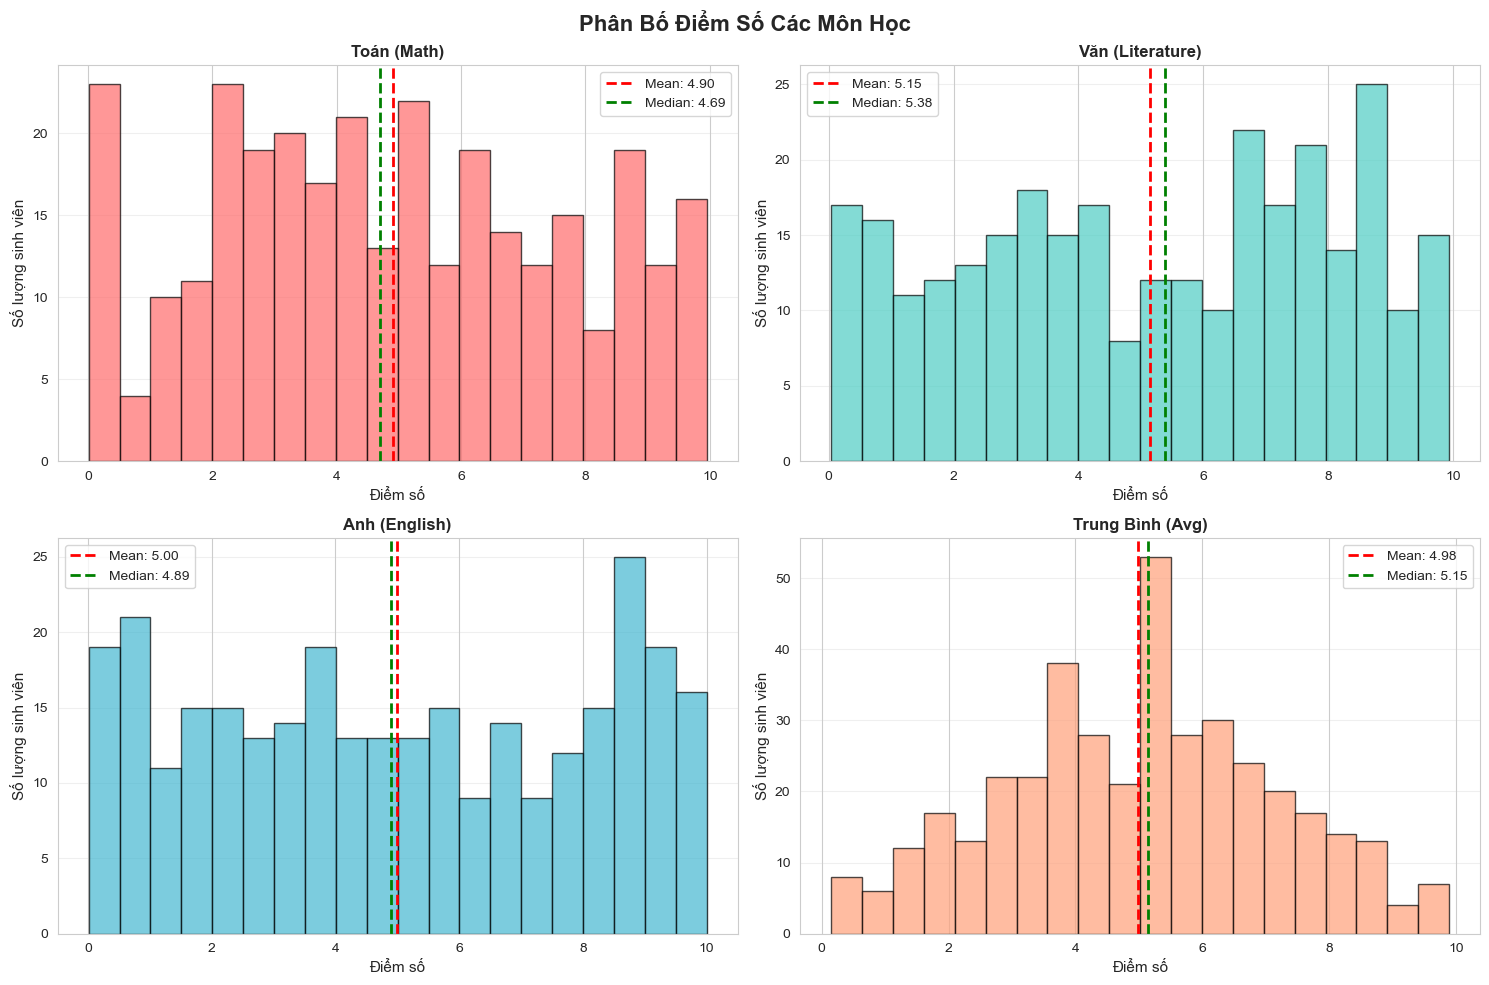


✓ Đã vẽ histogram phân bố điểm các môn học


In [38]:
# Histogram cho các môn học
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Phân Bố Điểm Số Các Môn Học', fontsize=16, fontweight='bold')

subjects = ['Math', 'Literature', 'Eng', 'Avg']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
titles = ['Toán (Math)', 'Văn (Literature)', 'Anh (English)', 'Trung Bình (Avg)']

for i, (subject, color, title) in enumerate(zip(subjects, colors, titles)):
    ax = axes[i // 2, i % 2]
    ax.hist(df[subject].dropna(), bins=20, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(df[subject].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[subject].mean():.2f}')
    ax.axvline(df[subject].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[subject].median():.2f}')
    ax.set_xlabel('Điểm số', fontsize=11)
    ax.set_ylabel('Số lượng sinh viên', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Đã vẽ histogram phân bố điểm các môn học")

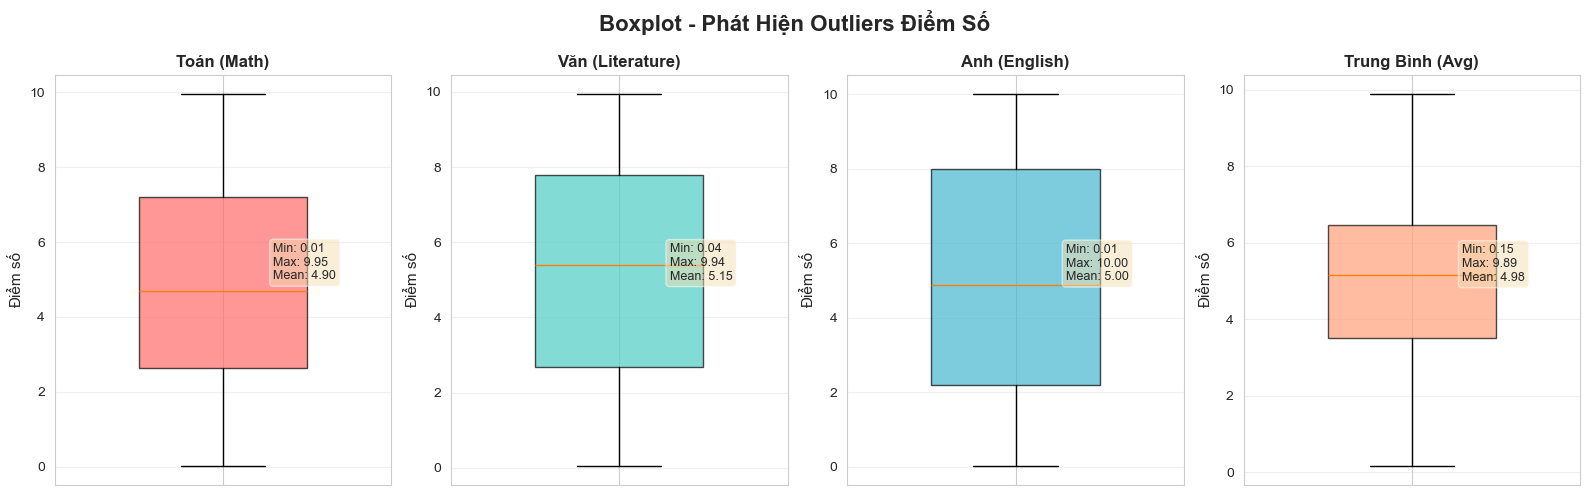


✓ Đã vẽ boxplot phát hiện outliers


In [ ]:
# Boxplot để phát hiện outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Boxplot - Phát Hiện Outliers Điểm Số', fontsize=16, fontweight='bold')

for i, (subject, color, title) in enumerate(zip(subjects, colors, titles)):
    ax = axes[i]
    bp = ax.boxplot(df[subject].dropna(), patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_ylabel('Điểm số', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels([''])
    ax.grid(axis='y', alpha=0.3)
    
    # Thêm thông tin thống kê
    stats_text = f"Min: {df[subject].min():.2f}\nMax: {df[subject].max():.2f}\nMean: {df[subject].mean():.2f}"
    ax.text(1.15, 5, stats_text, transform=ax.transData, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

print("\nĐã vẽ boxplot phát hiện outliers")

# MỐC 4 - Phân tích so sánh và tương quan điểm số

In [ ]:
# Tính ma trận tương quan
correlation_matrix = df[['Math', 'Literature', 'Eng']].corr()

print("=" * 70)
print("PHÂN TÍCH TƯƠNG QUAN ĐIỂM SỐ")
print("=" * 70)

print("\nMa trận tương quan:")
print(correlation_matrix.round(3))

# Phân tích chi tiết
print("\nPhân tích tương quan:")
corr_math_eng = correlation_matrix.loc['Math', 'Eng']
corr_lit_eng = correlation_matrix.loc['Literature', 'Eng']
corr_math_lit = correlation_matrix.loc['Math', 'Literature']

def interpret_correlation(corr):
    if abs(corr) < 0.3:
        return "Yếu"
    elif abs(corr) < 0.7:
        return "Trung bình"
    else:
        return "Mạnh"

print(f"  Math - Eng:        {corr_math_eng:.3f} ({interpret_correlation(corr_math_eng)})")
print(f"  Literature - Eng:  {corr_lit_eng:.3f} ({interpret_correlation(corr_lit_eng)})")
print(f"  Math - Literature: {corr_math_lit:.3f} ({interpret_correlation(corr_math_lit)})")

📊 PHÂN TÍCH TƯƠNG QUAN ĐIỂM SỐ

📈 Ma trận tương quan:
             Math  Literature    Eng
Math        1.000       0.029  0.025
Literature  0.029       1.000  0.042
Eng         0.025       0.042  1.000

✓ Phân tích tương quan:
  Math ↔ Eng:        0.025 (Yếu)
  Literature ↔ Eng:  0.042 (Yếu)
  Math ↔ Literature: 0.029 (Yếu)


### Scatter Plot - Tương quan giữa các môn

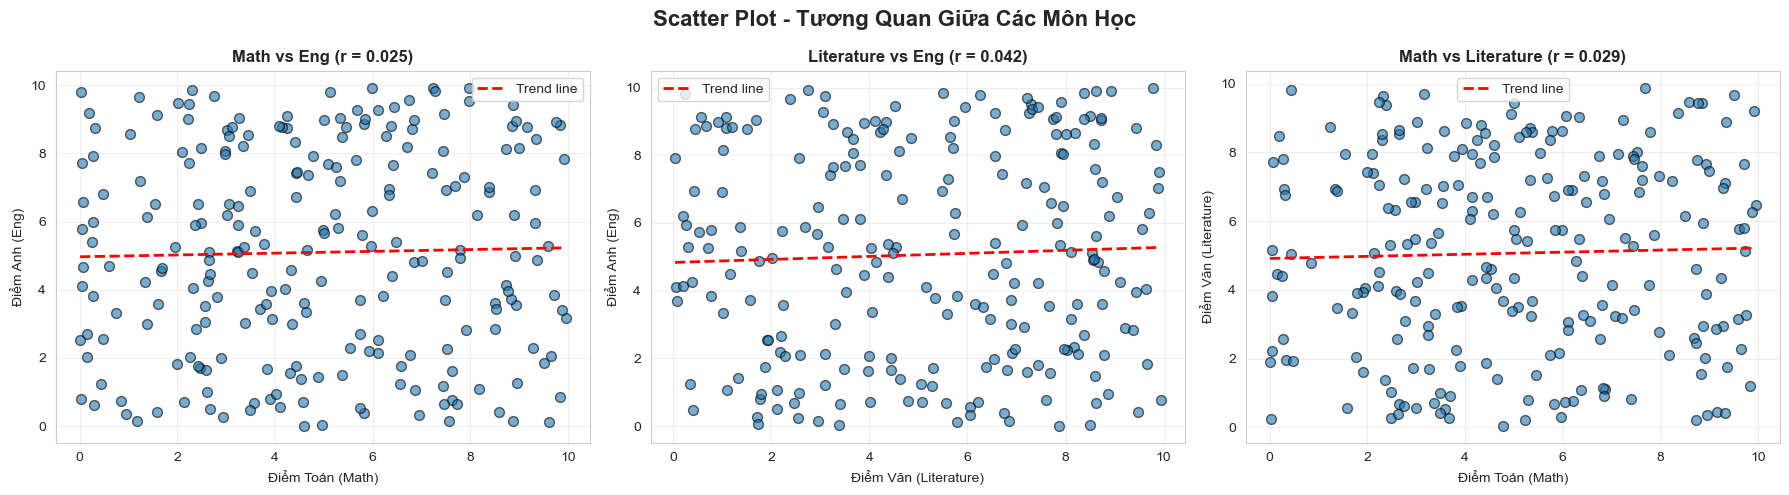

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Scatter Plot - Tương Quan Giữa Các Môn Học',
    fontsize=16,
    fontweight='bold'
)

# -------- Math vs Eng --------
subset = df[['Math', 'Eng']].dropna()

axes[0].scatter(
    subset['Math'],
    subset['Eng'],
    alpha=0.6,
    edgecolors='black',
    s=50
)

z = np.polyfit(subset['Math'], subset['Eng'], 1)
p = np.poly1d(z)
x_sorted = np.sort(subset['Math'])

axes[0].plot(
    x_sorted,
    p(x_sorted),
    'r--',
    linewidth=2,
    label='Trend line'
)

axes[0].set_xlabel('Điểm Toán (Math)')
axes[0].set_ylabel('Điểm Anh (Eng)')
axes[0].set_title(f'Math vs Eng (r = {corr_math_eng:.3f})', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()


# -------- Literature vs Eng --------
subset = df[['Literature', 'Eng']].dropna()

axes[1].scatter(
    subset['Literature'],
    subset['Eng'],
    alpha=0.6,
    edgecolors='black',
    s=50
)

z = np.polyfit(subset['Literature'], subset['Eng'], 1)
p = np.poly1d(z)
x_sorted = np.sort(subset['Literature'])

axes[1].plot(
    x_sorted,
    p(x_sorted),
    'r--',
    linewidth=2,
    label='Trend line'
)

axes[1].set_xlabel('Điểm Văn (Literature)')
axes[1].set_ylabel('Điểm Anh (Eng)')
axes[1].set_title(f'Literature vs Eng (r = {corr_lit_eng:.3f})', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()


# -------- Math vs Literature --------
subset = df[['Math', 'Literature']].dropna()

axes[2].scatter(
    subset['Math'],
    subset['Literature'],
    alpha=0.6,
    edgecolors='black',
    s=50
)

z = np.polyfit(subset['Math'], subset['Literature'], 1)
p = np.poly1d(z)
x_sorted = np.sort(subset['Math'])

axes[2].plot(
    x_sorted,
    p(x_sorted),
    'r--',
    linewidth=2,
    label='Trend line'
)

axes[2].set_xlabel('Điểm Toán (Math)')
axes[2].set_ylabel('Điểm Văn (Literature)')
axes[2].set_title(f'Math vs Literature (r = {corr_math_lit:.3f})', fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

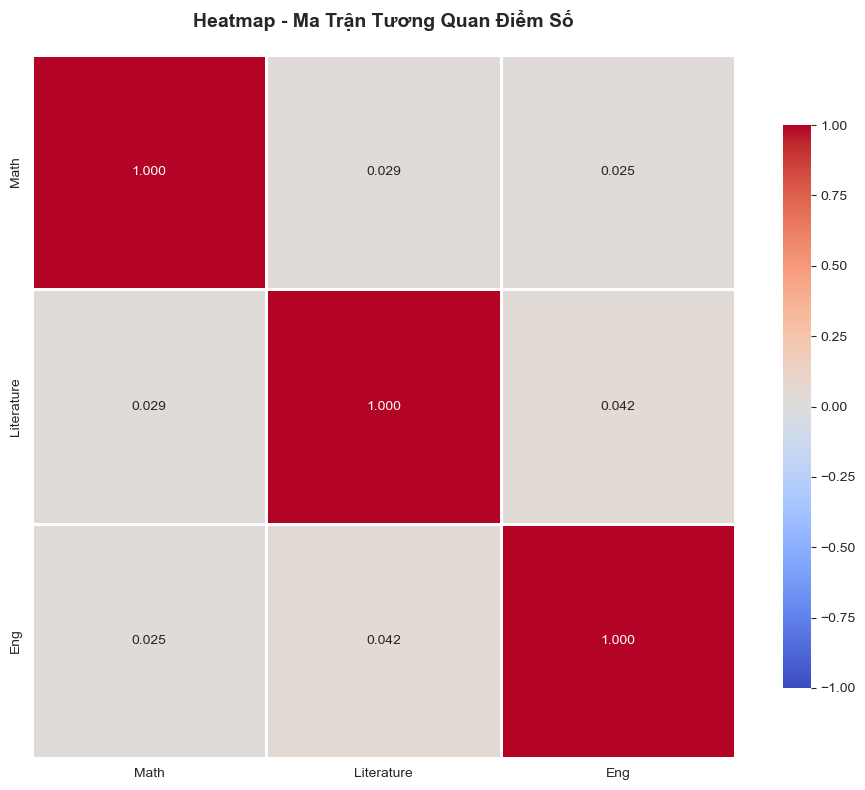


✓ Đã vẽ heatmap ma trận tương quan


In [ ]:
# Heatmap correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Heatmap - Ma Trận Tương Quan Điểm Số', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nĐã vẽ heatmap ma trận tương quan")

### Diễn giải kết quả

In [ ]:
print("\n" + "=" * 70)
print("DIỄN GIẢI KẾT QUẢ TƯƠNG QUAN")
print("=" * 70)

print(f"\n1. Tương quan Math - Eng ({corr_math_eng:.3f}):")
if corr_math_eng > 0.3:
    print("   Có tương quan dương, sinh viên giỏi Toán thường cũng giỏi Anh.")
    print("   Cả hai môn đều yêu cầu tư duy logic và khả năng phân tích.")
else:
    print("   Tương quan yếu, kết quả Toán và Anh không phụ thuộc nhiều vào nhau.")

print(f"\n2. Tương quan Literature - Eng ({corr_lit_eng:.3f}):")
if corr_lit_eng > 0.3:
    print("   Có tương quan dương, sinh viên giỏi Văn thường cũng giỏi Anh.")
    print("   Cả hai môn đều là ngôn ngữ, yêu cầu kỹ năng đọc hiểu và diễn đạt.")
else:
    print("   Tương quan yếu, kỹ năng tiếng mẹ đẻ không đảm bảo kỹ năng ngoại ngữ.")

print(f"\n3. Tương quan Math - Literature ({corr_math_lit:.3f}):")
if corr_math_lit > 0.3:
    print("   Có tương quan dương, sinh viên học tốt thường giỏi cả hai môn.")
    print("   Phản ánh năng lực học tập tổng thể của sinh viên.")
else:
    print("   Tương quan yếu, Toán và Văn là hai lĩnh vực khác biệt.")
    print("   Sinh viên có thể giỏi môn này nhưng yếu môn kia.")


📝 DIỄN GIẢI KẾT QUẢ TƯƠNG QUAN

1. Tương quan Math - Eng (0.025):
   → Tương quan yếu, kết quả Toán và Anh không phụ thuộc nhiều vào nhau.

2. Tương quan Literature - Eng (0.042):
   → Tương quan yếu, kỹ năng tiếng mẹ đẻ không đảm bảo kỹ năng ngoại ngữ.

3. Tương quan Math - Literature (0.029):
   → Tương quan yếu, Toán và Văn là hai lĩnh vực khác biệt.
   → Sinh viên có thể giỏi môn này nhưng yếu môn kia.


# MỐC 5 - Phân tích theo quê quán

In [ ]:
# Thống kê theo quê quán
print("=" * 70)
print("PHÂN TÍCH THEO QUÊ QUÁN")
print("=" * 70)

print("\nSố lượng sinh viên theo quê quán:")
hometown_counts = df['Hometown'].value_counts()
for hometown, count in hometown_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {hometown:15} : {count:3} sinh viên ({pct:5.2f}%)")

# So sánh điểm trung bình theo quê quán
print("\nĐiểm trung bình các môn theo quê quán:")
hometown_avg = df.groupby('Hometown')[['Math', 'Literature', 'Eng', 'Avg']].mean()
print(hometown_avg.round(2))

📊 PHÂN TÍCH THEO QUÊ QUÁN

✓ Số lượng sinh viên theo quê quán:
  Khác            : 193 sinh viên (48.25%)
  TP.HCM          : 112 sinh viên (28.00%)
  Hà Nội          :  95 sinh viên (23.75%)

✓ Điểm trung bình các môn theo quê quán:
          Math  Literature   Eng   Avg
Hometown                              
Hà Nội    4.43        5.07  4.96  4.85
Khác      5.22        5.08  5.02  5.06
TP.HCM    4.72        5.34  4.99  4.97


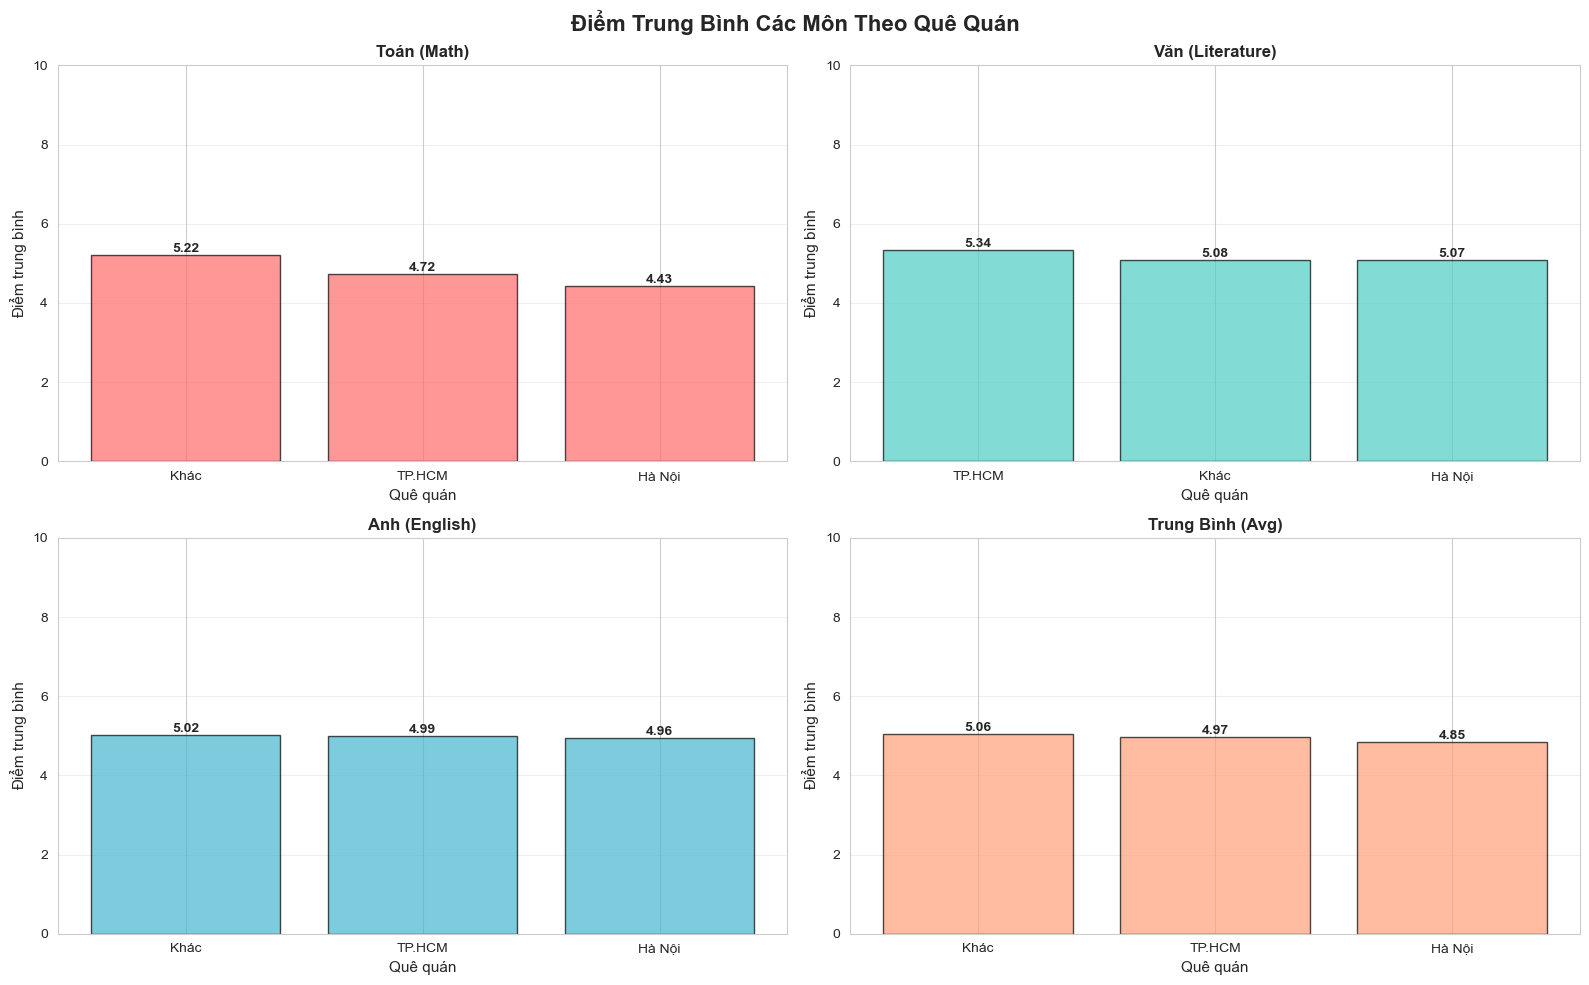


✓ Đã vẽ bar chart điểm trung bình theo quê quán


In [ ]:
# Bar chart điểm trung bình theo quê quán
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Điểm Trung Bình Các Môn Theo Quê Quán', fontsize=16, fontweight='bold')

subjects_with_avg = ['Math', 'Literature', 'Eng', 'Avg']
titles_with_avg = ['Toán (Math)', 'Văn (Literature)', 'Anh (English)', 'Trung Bình (Avg)']
colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, (subject, title, color) in enumerate(zip(subjects_with_avg, titles_with_avg, colors_list)):
    ax = axes[i // 2, i % 2]
    hometown_subject_avg = df.groupby('Hometown')[subject].mean().sort_values(ascending=False)
    bars = ax.bar(hometown_subject_avg.index, hometown_subject_avg.values, color=color, alpha=0.7, edgecolor='black')
    
    # Thêm giá trị trên mỗi cột
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Quê quán', fontsize=11)
    ax.set_ylabel('Điểm trung bình', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

print("\nĐã vẽ bar chart điểm trung bình theo quê quán")

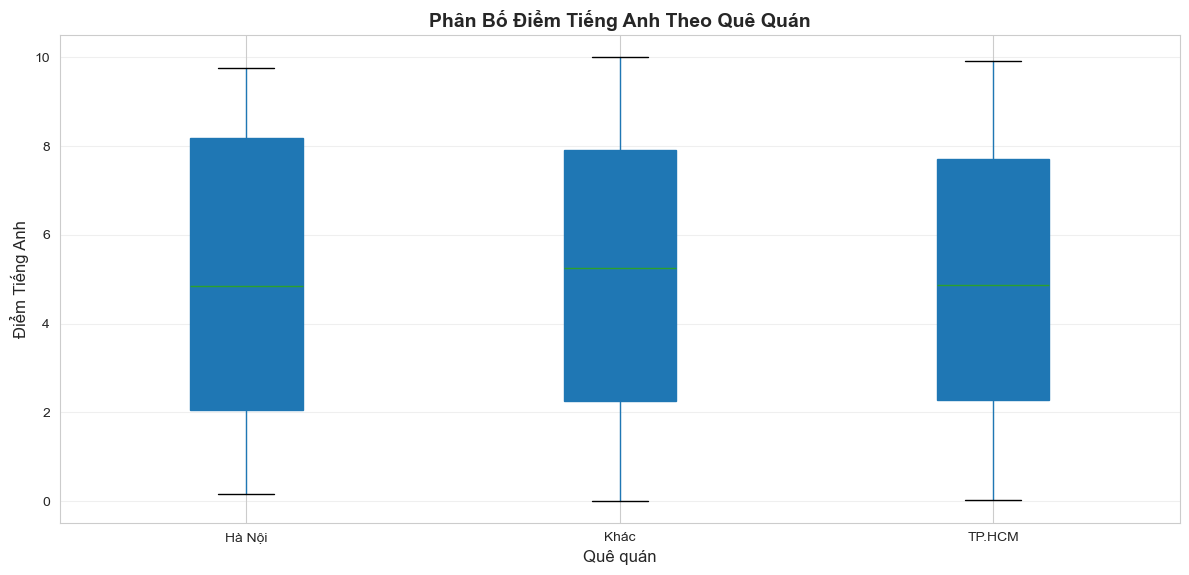


✓ Đã vẽ boxplot phân bố điểm Tiếng Anh theo quê quán


In [ ]:
# Boxplot phân bố điểm Tiếng Anh theo quê quán
plt.figure(figsize=(12, 6))
df.boxplot(column='Eng', by='Hometown', ax=plt.gca(), 
           patch_artist=True, grid=True)
plt.suptitle('')  # Remove default title
plt.title('Phân Bố Điểm Tiếng Anh Theo Quê Quán', fontsize=14, fontweight='bold')
plt.xlabel('Quê quán', fontsize=12)
plt.ylabel('Điểm Tiếng Anh', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nĐã vẽ boxplot phân bố điểm Tiếng Anh theo quê quán")

### Nhận xét sự khác biệt

In [ ]:
print("\n" + "=" * 70)
print("NHẬN XÉT VÀ XU HƯỚNG THEO QUÊ QUÁN")
print("=" * 70)

# So sánh thành phố lớn vs tỉnh khác
big_cities = df[df['Hometown'].isin(['Hà Nội', 'TP.HCM'])]
others = df[df['Hometown'] == 'Khác']

print("\n1. So sánh Thành phố lớn (HN, HCM) vs Tỉnh khác:")
print(f"   Thành phố lớn - Avg: {big_cities['Avg'].mean():.2f}")
print(f"   Tỉnh khác - Avg: {others['Avg'].mean():.2f}")

if big_cities['Avg'].mean() > others['Avg'].mean():
    diff = big_cities['Avg'].mean() - others['Avg'].mean()
    print(f"   Sinh viên từ thành phố lớn có điểm cao hơn {diff:.2f} điểm")
    print("   Có thể do điều kiện học tập tốt hơn ở thành phố lớn")
else:
    print("   Không có sự chênh lệch đáng kể theo địa lý")

print("\n2. Điểm Tiếng Anh:")
print(f"   Hà Nội: {df[df['Hometown']=='Hà Nội']['Eng'].mean():.2f}")
print(f"   TP.HCM: {df[df['Hometown']=='TP.HCM']['Eng'].mean():.2f}")
print(f"   Khác: {df[df['Hometown']=='Khác']['Eng'].mean():.2f}")

best_hometown_eng = hometown_avg['Eng'].idxmax()
print(f"   Sinh viên từ {best_hometown_eng} có điểm Anh cao nhất")


📝 NHẬN XÉT VÀ XU HƯỚNG THEO QUÊ QUÁN

1. So sánh Thành phố lớn (HN, HCM) vs Tỉnh khác:
   Thành phố lớn - Avg: 4.92
   Tỉnh khác - Avg: 5.06
   → Không có sự chênh lệch đáng kể theo địa lý

2. Điểm Tiếng Anh:
   Hà Nội: 4.96
   TP.HCM: 4.99
   Khác: 5.02
   → Sinh viên từ Khác có điểm Anh cao nhất


# MỐC 6 - Phân tích theo độ tuổi

In [ ]:
# Nhóm tuổi
def group_age(age):
    if pd.isna(age):
        return 'Không xác định'
    elif age <= 20:
        return '≤ 20'
    elif age <= 22:
        return '21-22'
    else:
        return '≥ 23'

df['AgeGroup'] = df['Age'].apply(group_age)

print("=" * 70)
print("PHÂN TÍCH THEO ĐỘ TUỔI")
print("=" * 70)

print("\nPhân bố nhóm tuổi:")
age_group_counts = df['AgeGroup'].value_counts()
for group in ['≤ 20', '21-22', '≥ 23']:
    if group in age_group_counts.index:
        count = age_group_counts[group]
        pct = (count / len(df)) * 100
        print(f"  {group:15} : {count:3} sinh viên ({pct:5.2f}%)")

print("\nĐiểm trung bình theo nhóm tuổi:")
age_group_avg = df[df['AgeGroup'] != 'Không xác định'].groupby('AgeGroup')[['Math', 'Literature', 'Eng', 'Avg']].mean()
print(age_group_avg.round(2))

📊 PHÂN TÍCH THEO ĐỘ TUỔI

✓ Phân bố nhóm tuổi:
  ≤ 20            : 149 sinh viên (37.25%)
  21-22           : 119 sinh viên (29.75%)
  ≥ 23            :  48 sinh viên (12.00%)

✓ Điểm trung bình theo nhóm tuổi:
          Math  Literature   Eng   Avg
AgeGroup                              
21-22     5.30        4.95  5.25  5.06
≤ 20      4.79        5.22  4.93  4.95
≥ 23      4.72        4.77  5.18  5.09


LinAlgError: SVD did not converge in Linear Least Squares

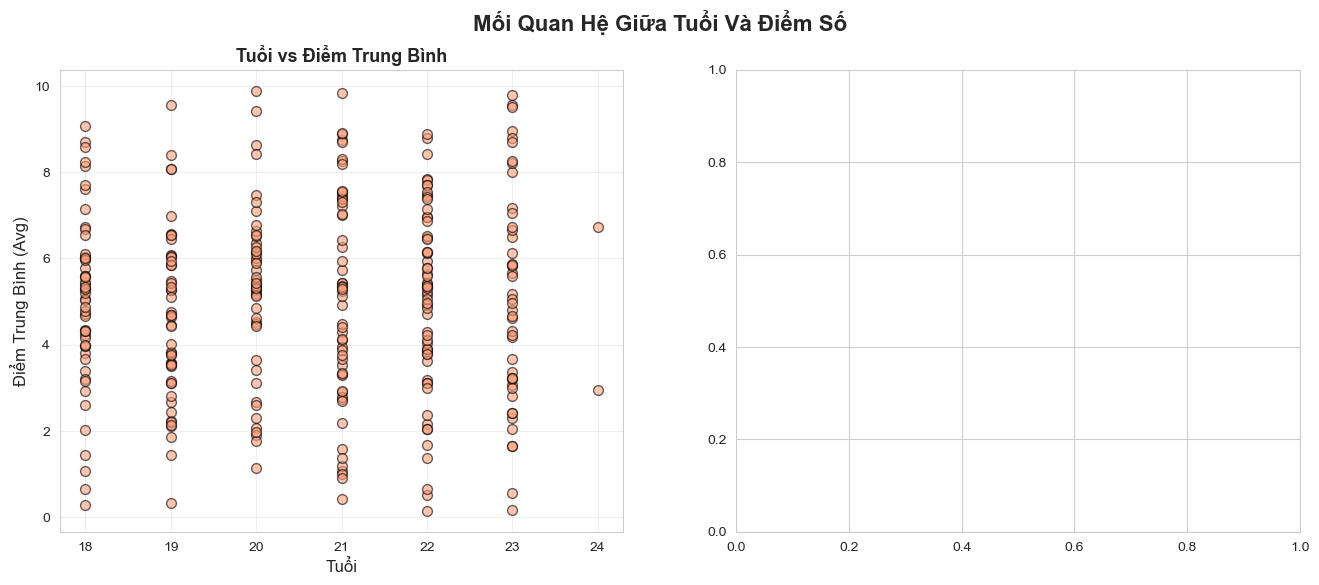

In [ ]:
# Scatter plot Age - Avg
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mối Quan Hệ Giữa Tuổi Và Điểm Số', fontsize=16, fontweight='bold')

# Age vs Avg
df_with_age = df[df['Age'].notna()]
axes[0].scatter(df_with_age['Age'], df_with_age['Avg'], alpha=0.6, color='#FFA07A', 
                edgecolors='black', s=50)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Điểm Trung Bình (Avg)', fontsize=12)
axes[0].set_title('Tuổi vs Điểm Trung Bình', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df_with_age['Age'], df_with_age['Avg'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df_with_age['Age']), p(sorted(df_with_age['Age'])), 
             "r--", alpha=0.8, linewidth=2, label='Trend line')
axes[0].legend()

# Age vs Eng
axes[1].scatter(df_with_age['Age'], df_with_age['Eng'], alpha=0.6, color='#45B7D1', 
                edgecolors='black', s=50)
axes[1].set_xlabel('Tuổi', fontsize=12)
axes[1].set_ylabel('Điểm Tiếng Anh (Eng)', fontsize=12)
axes[1].set_title('Tuổi vs Điểm Tiếng Anh', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df_with_age['Age'], df_with_age['Eng'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df_with_age['Age']), p(sorted(df_with_age['Age'])), 
             "r--", alpha=0.8, linewidth=2, label='Trend line')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nĐã vẽ scatter plot tuổi và điểm số")

### Nhận xét xu hướng theo tuổi

In [ ]:
print("\n" + "=" * 70)
print("NHẬN XÉT XU HƯỚNG THEO ĐỘ TUỔI")
print("=" * 70)

# Tính correlation
corr_age_avg = df[['Age', 'Avg']].corr().iloc[0, 1]
corr_age_eng = df[['Age', 'Eng']].corr().iloc[0, 1]

print(f"\n1. Tương quan Tuổi - Điểm Trung Bình: {corr_age_avg:.3f}")
if corr_age_avg > 0.1:
    print("   Sinh viên lớn tuổi hơn có xu hướng điểm cao hơn")
    print("   Có thể do trải nghiệm và sự trưởng thành")
elif corr_age_avg < -0.1:
    print("   Sinh viên trẻ tuổi hơn có xu hướng điểm cao hơn")
    print("   Có thể do tiếp thu kiến thức nhanh hơn")
else:
    print("   Không có mối liên hệ rõ ràng giữa tuổi và điểm số")
    print("   Kết quả học tập không phụ thuộc nhiều vào độ tuổi")

print(f"\n2. Tương quan Tuổi - Điểm Tiếng Anh: {corr_age_eng:.3f}")
if corr_age_eng > 0.1:
    print("   Sinh viên lớn tuổi hơn có điểm Anh cao hơn")
    print("   Có thể do thời gian học và rèn luyện nhiều hơn")
elif corr_age_eng < -0.1:
    print("   Sinh viên trẻ tuổi hơn có điểm Anh cao hơn")
    print("   Có thể do tiếp xúc sớm với ngoại ngữ")
else:
    print("   Không có mối liên hệ rõ ràng giữa tuổi và điểm Anh")

# MỐC 7 - Phân tích phục vụ quản lý sinh viên

In [ ]:
print("=" * 70)
print("PHÂN TÍCH PHỤC VỤ QUẢN LÝ SINH VIÊN")
print("=" * 70)

# Top 10 sinh viên có Avg cao nhất
print("\nTOP 10 SINH VIÊN CÓ ĐIỂM TRUNG BÌNH CAO NHẤT:")
top_10_students = df.nlargest(10, 'Avg')[['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg']]
print(top_10_students.to_string(index=False))

# Top sinh viên giỏi Tiếng Anh
print("\nTOP 10 SINH VIÊN GIỎI TIẾNG ANH:")
top_eng_students = df.nlargest(10, 'Eng')[['ID', 'Fullname', 'Hometown', 'Eng', 'Avg']]
print(top_eng_students.to_string(index=False))

📊 PHÂN TÍCH PHỤC VỤ QUẢN LÝ SINH VIÊN

🏆 TOP 10 SINH VIÊN CÓ ĐIỂM TRUNG BÌNH CAO NHẤT:
    ID          Fullname Hometown  Math  Literature   Eng  Avg
SV1132  Thành Văn Nguyễn     Khác   NaN        9.78 10.00 9.89
SV1267  Hoàng Quang Phạm   TP.HCM   NaN         NaN  9.84 9.84
SV1232        Xuân Hoàng   Hà Nội  9.78         NaN   NaN 9.78
SV1104    Bảo Quang Đặng     Khác   NaN         NaN  9.57 9.57
SV1088          Chi Đặng     Khác  9.91        9.20   NaN 9.56
SV1193       Nhiên Hoàng   TP.HCM   NaN        9.51   NaN 9.51
SV1012        Hải Tấn Vũ   TP.HCM   NaN        9.43   NaN 9.43
SV1209      Thành Nguyễn     Khác  9.35        8.90   NaN 9.12
SV1286 Châu Quang Nguyễn   TP.HCM   NaN        9.84  8.31 9.07
SV1026           Tú Trần   Hà Nội  8.86        9.43  8.80 9.03

🌟 TOP 10 SINH VIÊN GIỎI TIẾNG ANH:
    ID         Fullname Hometown   Eng  Avg
SV1132 Thành Văn Nguyễn     Khác 10.00 9.89
SV1043           An Mai     Khác  9.93 6.89
SV1214        Hạnh Trần   TP.HCM  9.91 8.17
SV1235  

### Danh sách cảnh báo

In [ ]:
# Sinh viên có Avg < 5
print("\nDANH SÁCH SINH VIÊN CẦN HỖ TRỢ (Avg < 5):")
weak_students = df[df['Avg'] < 5][['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg']].sort_values('Avg')
if len(weak_students) > 0:
    print(weak_students.to_string(index=False))
    print(f"\nTổng số: {len(weak_students)} sinh viên")
else:
    print("Không có sinh viên nào có điểm trung bình < 5")

# Sinh viên có từ 2 môn trở lên dưới 5
print("\nDANH SÁCH SINH VIÊN CÓ TỪ 2 MÔN TRỞ LÊN DƯỚI 5 (Nguy cơ cao):")
df['FailedSubjects'] = ((df['Math'] < 5).astype(int) + 
                        (df['Literature'] < 5).astype(int) + 
                        (df['Eng'] < 5).astype(int))
high_risk_students = df[df['FailedSubjects'] >= 2][['ID', 'Fullname', 'Hometown', 'Math', 'Literature', 'Eng', 'Avg', 'FailedSubjects']].sort_values('FailedSubjects', ascending=False)
if len(high_risk_students) > 0:
    print(high_risk_students.to_string(index=False))
    print(f"\nTổng số: {len(high_risk_students)} sinh viên")
else:
    print("Không có sinh viên nào có từ 2 môn trở lên dưới 5")


⚠️ DANH SÁCH SINH VIÊN CẦN HỖ TRỢ (Avg < 5):
    ID          Fullname Hometown  Math  Literature  Eng  Avg
SV1086         Hữu Dương   TP.HCM   NaN         NaN 0.15 0.15
SV1115       Phương Phạm   Hà Nội   NaN         NaN 0.16 0.16
SV1126    Hải Hoàng Trần   TP.HCM   NaN        0.29  NaN 0.29
SV1054        Mai Nguyễn     Khác   NaN         NaN 0.34 0.34
SV1208     Lâm Phú Hoàng     Khác  0.02         NaN 0.80 0.41
SV1344          Dương Lê     Khác  0.29         NaN 0.62 0.45
SV1044       Hải Bảo Mai     Khác   NaN        0.51  NaN 0.51
SV1238       Thành Hoàng   TP.HCM   NaN        0.57  NaN 0.57
SV1290           Châu Lê   Hà Nội  0.95         NaN 0.35 0.65
SV1341      Nam Đức Trần   TP.HCM  1.17         NaN 0.16 0.66
SV1379       Khoa Nguyễn     Khác   NaN        1.74 0.07 0.90
SV1285        Hương Trần     Khác  1.58         NaN 0.41 1.00
SV1051            Hà Bùi   TP.HCM  1.07         NaN  NaN 1.07
SV1364        Lâm Nguyễn     Khác   NaN        1.07  NaN 1.07
SV1346        Dương Đặng

### Đề xuất hành động

In [ ]:
print("\n" + "=" * 70)
print("ĐỀ XUẤT HÀNH ĐỘNG QUẢN LÝ")
print("=" * 70)

print("\n1. HỖ TRỢ HỌC TẬP CHO SINH VIÊN YẾU:")
print(f"   Số lượng: {len(weak_students)} sinh viên có Avg < 5")
print("   Hành động:")
print("     - Tổ chức lớp học phụ đạo miễn phí")
print("     - Ghép đôi với sinh viên giỏi (peer tutoring)")
print("     - Tư vấn học tập 1-1 với giảng viên")
print("     - Cung cấp tài liệu học tập bổ sung")

print("\n2. TƯ VẤN HỌC TẬP CHO NHÓM NGUY CƠ:")
print(f"   Số lượng: {len(high_risk_students)} sinh viên có ≥2 môn dưới 5")
print("   Hành động:")
print("     - Gặp gỡ phụ huynh để trao đổi tình hình học tập")
print("     - Xem xét giảm tải môn học trong kỳ tới")
print("     - Hỗ trợ tâm lý nếu có vấn đề cá nhân ảnh hưởng học tập")
print("     - Lập kế hoạch học tập cá nhân hóa")

# Phân tích môn yếu nhất
avg_scores = {
    'Toán': df['Math'].mean(),
    'Văn': df['Literature'].mean(),
    'Anh': df['Eng'].mean()
}
weakest_subject = min(avg_scores, key=avg_scores.get)

print("\n3. CẢI THIỆN CHẤT LƯỢNG GIẢNG DẠY:")
print(f"   Môn yếu nhất: {weakest_subject} (điểm TB: {avg_scores[weakest_subject]:.2f})")
print("   Hành động:")
print("     - Đánh giá lại phương pháp giảng dạy")
print("     - Tăng cường bài tập thực hành")
print("     - Sử dụng công nghệ và phương pháp giảng dạy hiện đại")

print("\n4. KHEN THƯỞNG VÀ ĐỘNG VIÊN:")
print("   Top 10 sinh viên xuất sắc nhất")
print("   Hành động:")
print("     - Trao học bổng khuyến khích")
print("     - Vinh danh trước toàn trường")
print("     - Mời làm trợ giảng hoặc peer tutor")

print("\n" + "=" * 70)


💡 ĐỀ XUẤT HÀNH ĐỘNG QUẢN LÝ

1. 🎓 HỖ TRỢ HỌC TẬP CHO SINH VIÊN YẾU:
   • Số lượng: 187 sinh viên có Avg < 5
   • Hành động:
     - Tổ chức lớp học phụ đạo miễn phí
     - Ghép đôi với sinh viên giỏi (peer tutoring)
     - Tư vấn học tập 1-1 với giảng viên
     - Cung cấp tài liệu học tập bổ sung

2. ⚠️ TƯ VẤN HỌC TẬP CHO NHÓM NGUY CƠ:
   • Số lượng: 134 sinh viên có ≥2 môn dưới 5
   • Hành động:
     - Gặp gỡ phụ huynh để trao đổi tình hình học tập
     - Xem xét giảm tải môn học trong kỳ tới
     - Hỗ trợ tâm lý nếu có vấn đề cá nhân ảnh hưởng học tập
     - Lập kế hoạch học tập cá nhân hóa

3. 📚 CẢI THIỆN CHẤT LƯỢNG GIẢNG DẠY:
   • Môn yếu nhất: Toán (điểm TB: 4.90)
   • Hành động:
     - Đánh giá lại phương pháp giảng dạy
     - Tăng cường bài tập thực hành
     - Sử dụng công nghệ và phương pháp giảng dạy hiện đại

4. 🌟 KHEN THƯỞNG VÀ ĐỘNG VIÊN:
   • Top 10 sinh viên xuất sắc nhất
   • Hành động:
     - Trao học bổng khuyến khích
     - Vinh danh trước toàn trường
     - Mời làm t

## Tổng kết và Kết luận

In [ ]:
print("\n" + "=" * 70)
print("TỔNG KẾT DỰ ÁN PHÂN TÍCH DỮ LIỆU SINH VIÊN")
print("=" * 70)

print("\nĐã hoàn thành:")
print("   MỐC 1: Làm sạch dữ liệu thô (Data Cleaning)")
print("   MỐC 2: Kiểm tra và xác nhận dữ liệu sạch")
print("   MỐC 3: Phân tích mô tả dữ liệu")
print("   MỐC 4: Phân tích tương quan điểm số")
print("   MỐC 5: Phân tích theo quê quán")
print("   MỐC 6: Phân tích theo độ tuổi")
print("   MỐC 7: Phân tích phục vụ quản lý sinh viên")

print("\nKết quả chính:")
print(f"   Dữ liệu ban đầu: {len(df_raw)} sinh viên")
print(f"   Dữ liệu sạch: {len(df)} sinh viên")
print(f"   Điểm trung bình chung: {df['Avg'].mean():.2f}")
print(f"   Sinh viên giỏi (Avg ≥ 8): {len(df[df['Avg'] >= 8])} ({len(df[df['Avg'] >= 8])/len(df)*100:.1f}%)")
print(f"   Sinh viên yếu (Avg < 5): {len(df[df['Avg'] < 5])} ({len(df[df['Avg'] < 5])/len(df)*100:.1f}%)")

print("\nFile output:")
print("   - students_clean.xlsx: Dữ liệu sạch đã được xuất")

print("\nDự án hoàn thành!")
print("=" * 70)